# Autoestudio 3 - Programacion dinamica

Al finalizar este autoestudio debe adquirir conocimiento para:

1. Identificar si un problema se puede tratar con la técnica de programación dinamica
1. Desarrollar soluciones aplicando la técnica de programación dinámica
1. Aplicar la tecnica de programacion dinamica de Top-Down

In [ ]:
# @title Ingrese datos
estudiante = " " # @param {"type":"string"}
carnet = 0 # @param {"type":"integer"}


# Introduccion

Programacion dinamica (DP) es una técnica de solución de problemas que de manera similar al metodo de divide y conquista (D&Q), vista anteriormente, resuelve problemas por medio de combinar las soluciones a subproblemas.

Los requisitos para que sea un problema de DP son:
- El problema tiene **subestructura óptima**: donde la solución general de un problema se puede ver como la combinación de soluciones a subproblemas.
- El problema tiene **subproblemas superpuestos**: cuando el mismo subproblema se resuelve varias veces en la solución de un problema mayor.

Una diferencia clave con D&Q es que este particiona el problema inicial en una serie de subproblemas disyuntos para luego combinarlos y dar solución al problema inicial. *Al ser disyuntos implica que no son superpuestos*.

En el contexto de problemas superpuestos, se podría terminar generando más trabajo del necesario, resolviendo el mismo subproblema repetidas veces. Un algoritmo DP resuelve cada subproblema sólo una vez, ahorrándose el trabajo de recomputar el mismo subproblema repetidamente.

---
Existen dos (2) tecnicas de programacion dinamica

 - Top-Down
 - Bottom-Up

En este laboratorio solo emplearemos la tecnica de Top-Down.






#Fibonacci

Un ejemplo clasico de DP es la función de Fibonacci, definida como una función recursiva de la forma:

$$f(n) = \begin{cases}
1 & \text{si } n = 0 \lor n = 1 \\
f(n-1) + f(n-2) & \text{si } n >= 2
\end{cases}
$$

Si ilustramos la cantidad de casos que se generan con $n=5$, tendremos el siguiente árbol.
- $f(5)=f(4)+f(3)$

- $f(4)=f(3)+f(2)$
- $...$

In [ ]:
#@title Subproblemas
n = 5 # @param {"type":"slider","min":1,"max":8,"step":1}

import graphviz

global_counter = 0

class Unique:
  def __init__(self, s):
    self.obj = s

  def __str__(self) -> str:
    return f"f({self.obj})"

  def __repr__(self) -> str:
    return self.__str__()

def add_edges(G, n: int, parent_id: str | None = None, depth: int = 0):
  global global_counter
  node = Unique(n)
  node_id = f"{id(node)}_{global_counter}"
  global_counter += 1
  G.node(node_id, label=f"{node}")
  if parent_id is not None:
    G.edge(parent_id, node_id)
  if n > 1:
    add_edges(G, n-1, node_id, depth + 1)
    add_edges(G, n-2, node_id, depth + 1)

def create_fib_tree(n: int):
  assert n >= 0
  graph = graphviz.Digraph()
  graph.strict = False

  add_edges(graph, n)
  return graph

fib_tree = create_fib_tree(n)
fib_tree

## $\color{blue}{Ejercicios}$

1. **Cuente** cuantas veces se calcula cada uno de los subproblemas que se repiten
2. **Experimente** con diferentes valores de $n$ en la casilla anterior y ejecútela.
3. **Argumente** para un $n$ cualquiera, ¿Cuantos nodos se generan y cuantos nodos son redundantes para la función `fibonacci`?
4. Observando que la función `fibonacci` es una forma de conteo, **investigue** de donde surgió la función originalmente, y de que es lo que hace conteo.

## Código

Codifiquemos la función `fibonacci` con solo recursion

In [ ]:
def fibonacci(n: int) -> int:
    if n <= 1:
        return 1
    else:
        return fibonacci(n-1) + fibonacci(n-2)

##Análisis de complejidad
Ahora computemos los tiempos de ejecucion para diferentes valores de $n = 1, \ldots, 40$.

Empecemos codificando una función de ayuda para medir los tiempos de ejecucion para diferentes valores de $n$.

In [ ]:
import time
import math
from typing import Callable

def compute_func_times(lim: int, func: Callable[[int], float], steps: int = 1) -> tuple[list[int], list[float]]:
  """
  Computa tiempos de ejecucion para una función que recibe un solo argumento numerico

  lim - limite de iteraciones que se realizaran
  func - función que se probara, esta recibe un solo argumento numerico
  steps - salto de intervalos para probar nuestra función (por omision 1)
  """

  print("Computando tiempos ...")
  x, y = [], []
  for n in range(0, lim+1, steps):
    ti = time.time()
    func(n)
    tf = time.time()
    delta = tf - ti
    print(n, f"\rn = {n} -> {delta:.4f}s", end="")
    x.append(n)
    y.append(delta)

  print("\nFinalizado")
  print(f"Tiempo total: {sum(y):.4f}s")
  return x, y

In [ ]:
n = 40
fib_times = compute_func_times(n, fibonacci)

Ahora grafiquemos los tiempos de ejecucion

In [ ]:
import matplotlib.pyplot as plt

def dibujar(graphs: list, dims: tuple[int, int] = (7, 5), scale: str = "linear"):
  plt.figure(figsize=dims)
  plt.ylabel("tiempo")
  plt.xlabel("tamaño")
  plt.yscale(scale)
  for x, y in graphs:
    plt.plot(x, y)
  plt.show()

dibujar([fib_times])

El tiempo de ejecucion de `fibonacci` es $T_{\text{fib}}(n) = O(2^{n})$, como podemos observar del gráfico anterior. Más adelante veremos que la mayor parte del computo esta concentrado en resolver los mismos subproblemas una y otra vez.

## Técnica DP:Top-Down
Esta técnica consiste en realizar la recursión de manera tradicional, con **dos** (2) pasos adicionales:

1. Antes de cualquier operacion dentro de nuestra función, verificamos si la solución al subproblema actual ya fue computada, de ser asi, retornamos ese valor
2. Si no ha sido computada, la computamos de manera tradicional con la recursion, y guardamos el valor computado en la tabla de memorizacion.

Realizando este mismo ejercicio sobre `fibonacci`, creemos la función `fibonacci_memoized` aplicando esta tecnica.

##Código con DP

In [ ]:
def fibonacci_memoized(memo: list[int], n: int) -> int:
  # Si el valor ya fue computado, lo devolvemos
  if memo[n] != -1:
    return memo[n]

  # Sino, lo computamos de manera habitual
  if n == 0 or n == 1:
    return 1
  fib = fibonacci_memoized(memo, n-1) + fibonacci_memoized(memo, n-2)

  # ...  y lo guardamos en la tabla de memorizacion
  memo[n] = fib
  return fib

##Análisis de complejidad con DP

In [ ]:
import sys
sys.setrecursionlimit(20000) # debemos aumentar limites de recursion del programa

n = 19000
def measure_fibmem(n: int) -> int:
  memo: list[int] = [-1] * (n+1) # inicializamos tabla de memorizacion
  return fibonacci_memoized(memo, n)

fibmem_times = compute_func_times(n, measure_fibmem, 500)

In [ ]:
dibujar([fibmem_times])


Nótese que el tiempo de ejecucion paso de aproximadamente 25+ segundos para solo $n=40$ con solo recursion, a tan solo ser menos de $1/5$ de segundo calculando fibonacci para $n=19000$ usando memorizacion.

Las variaciones de tiempo de ejecucion en la grafica se deben a factores externos de la función que estamos haciendo prueba.

El tiempo de ejecucion para fibonacci con memorizacion es $T_{\text{fibmem}}(n) = O(n)$, esto debido a que la rama mas larga del árbol de recursion es precisamente $n$ elementos, luego de esto los calculos subsiguientes seran tan solo cuestion de revisar la tabla de memorizacion, donde en ese punto solo sera $\Theta(1)$ por consulta de cualquier numero $n$ que ya se haya precalculado.

Esto tambien se le conoce como "podar el árbol", debido a que estamos eliminando el calculo de todos los nodos redudantes que se encuentran en el árbol de recursion.

# Problema de "Cuente las maneras ..."

Una forma de ejercicios típicos que se encuentran en programación dinamica es la de el conteo de las formas de realizar alguna acción.

Tomemos un problema clásico de computación:

> **Problema de la rana**
>
> Hay una rana en un estanque, esta puede saltar entre hojas que se encuentran flotando sobre el agua (tambien conocidas como *nenufares*). La rana puede saltar entre $1$ y $k$ hojas a la vez. Supongamos que desde donde está llegar a la $n$-esima hoja. La pregunta es: ¿Cuantas maneras existen de llegar desde la posición de inicio hasta la ultima sabiendo que puede dar saltos de diferente longitud?




##Diseño
Para responder esta pregunta, empecemos identificando de manera visual como se determinaria la cantidad de maneras para la rana de recorrer el estanque.
Asumamos que la rana quiere llegar a su destino en $n=5$ y puede tomar de entre $1$ y $k=3$ pasos de longitud.

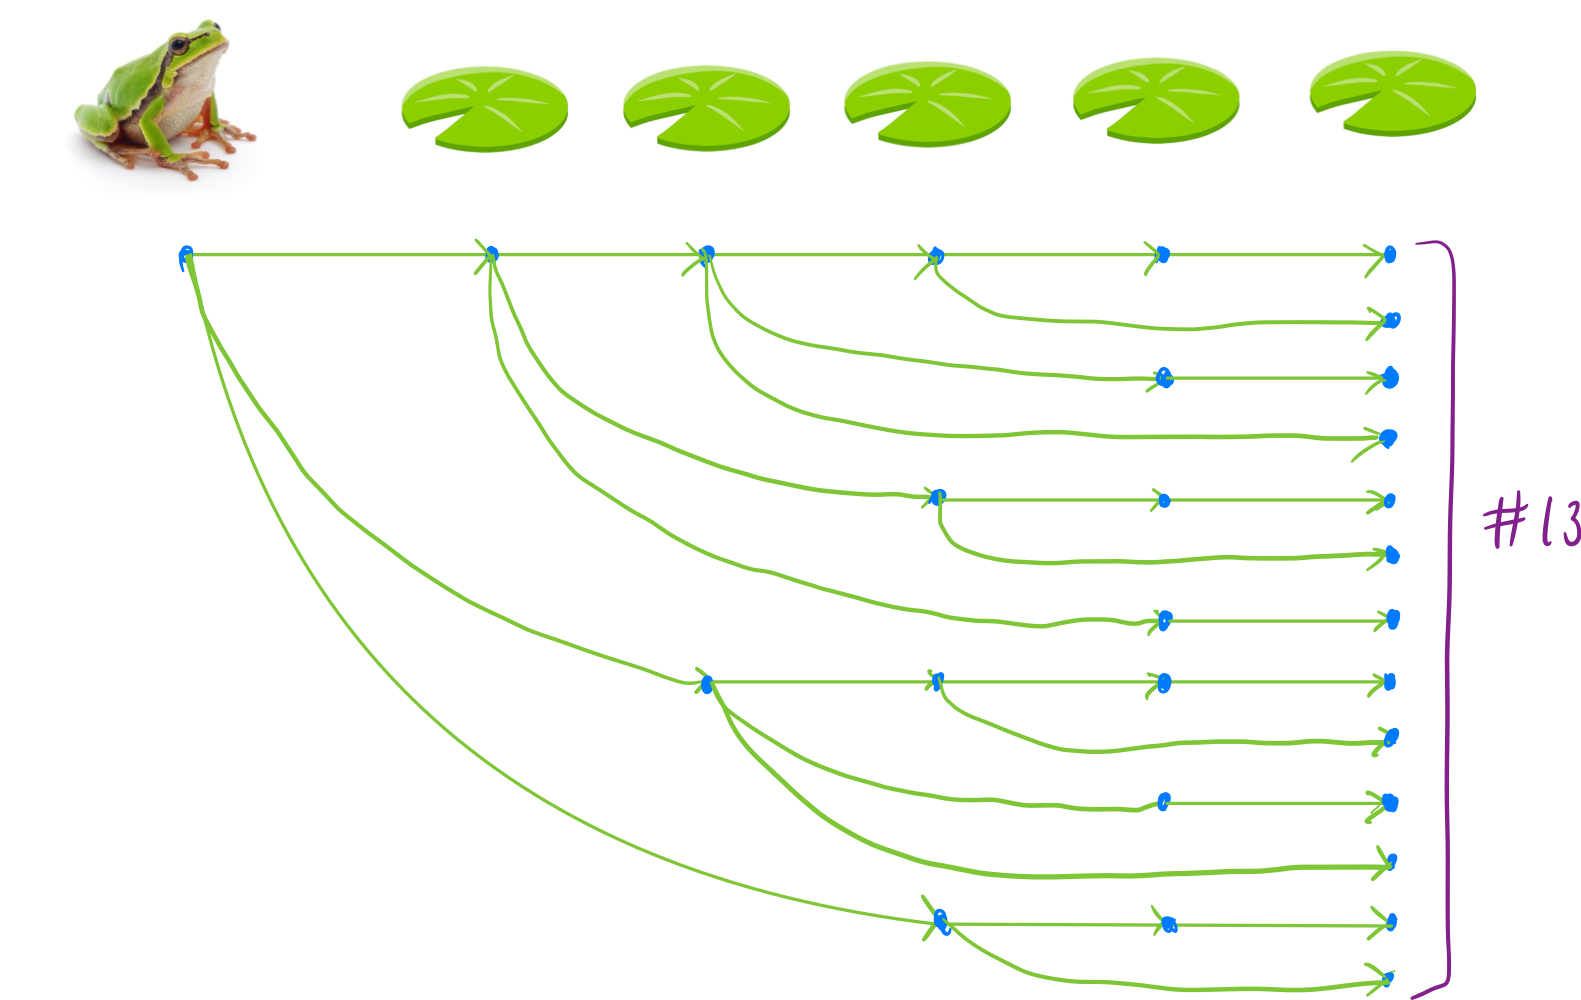

En el gráfico vemos que lo podría hacer de $13$ maneras distintas.

----
Si ahora queremos especificar esto con una formula recursiva,

$ \text{count}(k,n)=$
número de formas diferentes de llegar a la $n$-ésima hoja si puede saltar hasta $k$ hojas a la vez

**Caso base:** el caso base podemos especificarlo con $n=0$, sólo hay una forma de llegar al inicio. (e.g. $\text{count}(0) = 1$).

**Caso recursivo:**
Ahora considerando el caso recursivo, debemos pensar que si tenemos $k$ elecciones para iniciar el salto, debemos sumar todas las maneras de llegar a partir de estos $k$ inicios:

1. Si iniciamos dando un salto de 1, tendríamos $\text{count}(k, n-1)$ formas diferentes de llegar
2. Si iniciamos dando un salto de 2, tendríamos $\text{count}(k, n-2)$ formas diferentes de llegar
3. ..

El último salto con el que se puede iniciar es de min(n,k)

Por tanto


$$
\text{count}(k,n) = \text{count}(k,n-1) +
 \text{count}(k,n-2)
  + \cdots +
 \text{count}(k,n - (k-1)) +
  \text{count}(k,n-min(n,k))
$$

Sintetizando la función completa, tenemos

$$
\text{count}(k,n) = \begin{cases}
  1 & \text{si } n = 0 \\
  \sum_{i=1}^{\min(n,\ k)} \text{count}(k,n-i) & \text{si } n > 0 \\
\end{cases}
$$



##Código
Si codificamos esta función en Python, tendremos:

In [ ]:
def count(k: int, n: int) -> int:
  if n == 0:
    return 1

  s = 0
  for i in range(1, min(k,n)+1):
    s += count(k, n-i)

  return s

In [ ]:
print(count(k=3, n=5))

##$\color{blue}{Ejercicio. Código\ con\ DP}$

1. **Implemente** la función `count_memoized` usando la tecnica Top-Down sobre la función `count` definida más arriba con la explicacion del problema de la rana.

In [ ]:
def count_memoized(memo: list[int], k: int, n: int) -> int:
  # Implemente
  return 0

In [ ]:
print(count_memoized(k=3, n=5))

## $\color{blue}{Ejercicios}$

1. Considerando la formula general de conteo, ¿para que valor de $k$ tenemos a la función `fibonacci`?
2. Si la función de tiempo para fibonacci es $T_{\text{fib}}(n) = O(2^n)$, ¿Cual seria el tiempo asintotico para el conteo en función de $n$ y $k$?

# $\color{blue}{Ejercicios. Números\ mágicos.}$


Considere la siguiente función recursiva que calcula un número magico 🪄

In [ ]:
def magic(n: int) -> int:
  assert n >= 0
  if n == 0:
    return 2
  elif n == 1:
    return 3
  elif n == 2:
    return 3

  return 2 * magic(n-1) - 4 * magic(n-2) + 7 * magic(n-3)

In [ ]:
for n in range(15):
  print(f"magic({n}) = {magic(n)}")

1, **Implemente** `magic_memoized` aplicando la técnica Top-Down sobre el método `magic`

In [ ]:
def magic_memoized(memo: list[int], n: int) -> int:
  # Implemente
  return 0

2. **Argumente** cual es el limite asintotico de la función de tiempo $T(n)$ de la función `magic`. *Pista:* es una formula exponencial.

3. **Calcule** usando `magic_memoized` el valor cuando $n=900$. ¿Cuanto tiempo se demoro en calcular la respuesta? *Pista:* el numero calculado tiene 259 digitos.

In [ ]:
n = 900
memo = [-1] * (n+1)
val = magic_memoized(memo, n)

print("Digitos:", len(str(val)))
print(val)

4. **Ejecute** el mismo calculo con la función `magic`. ¿Que es lo que sucede?

5. Considerando su respuesta del punto `2`, ¿Cuanto **tiempo** cree que tomara para que se calcule la respuesta?

In [ ]:
print(magic(n))

# $\color{blue}{BONO.\ Palindromica.}$

---


Una secuencia de caracteres es *palindromica* cuando su lectura en los dos sentidos es la misma. Ejemplo de secuencias palindromicas son `A`, `ADA` y `RADAR`, mientras que `TAREA` y `ALGORITMO` no lo son.


##Especificación

>**Entrada**: Un arreglo $A = \langle A[0], \ldots, A[n-1] \rangle$.
>
>**Salida**: Longitud maxima de una subsecuencia palindromica en $A$.



##Diseño

Dado que `A`, `ADA` y `RADAR` son palindromicas, la longitud maxima de una subsecuencia palindromica en cada caso es $1$, $3$ y $5$, respectivamente. Para `TAREA` y `ALGORITMO`, la respuesta es coincidencialmente $3$.

Para $0 \leq m < N$ y $0 \leq n < N$, se propone la función $\phi$:
> $\phi(A, m, n)$: "longitud maxima de una subsecuencia palindromica en $A$ entre $m$ y $n$."

definida recurrentemente de la siguiente manera:

$$
\phi(A, m, n) = \begin{cases}
      0 & \text{si } m \geq n \\
      1 & \text{si } m + 1 = n \\
      \max\left( \phi(A, m+1, n),\, \phi(A, m, n-1) \right) & \text{si } m+1 < n \land A[m] \neq A[n-1] \\
      2 + \phi\left(A, m+1, n-1 \right) & \text{si } m+1 < n \land A[m] = A[n-1] \\
    \end{cases}
$$


El estado objetivo de la función es $\phi(A,0, N-1)$.



##Código

In [ ]:
# list | str significa que podemos recibir una lista O una cadena de caracteres

def phi(A: list | str, m: int, n: int) -> int:
  if m >= n:
    return 0
  elif m + 1 == n:
    return 1
  elif m + 1 < n and A[m] != A[n-1]:
    a = phi(A, m+1, n)
    b = phi(A, m, n-1)
    return max(a, b)
  elif m + 1 < n and A[m] == A[n-1]:
    return 2 + phi(A, m+1, n-1)

  return 0

In [ ]:
S = ["A", "ADA", "RADAR", "TAREA", "ALGORITMO"]
for s in S:
  print(s, phi(s, 0, len(s)))

##Preguntas

1. **Explique** el diseño de la función recursiva $\phi(A, m,n)$

2. **Implemente** la función `phi_memoized` aplicando la tecnica top-down sobre la función `phi` y muestre que funcióna con casos mucho mas grandes a los que se pueden lograr con la función original.


In [ ]:
def phi_memoized(memo, A: list | str, m: int, n: int) -> int:
  # Implemente
  return 0

3. **Especifique** el limite asintotico $T(n)$ de la función `phi` y de `phi_memoized`.